<a href="https://colab.research.google.com/github/kumisganteng/Data-Analytics-Projects/blob/main/Improving_Customer_Retention_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Nama : Ganendra Satya Sindhunata
##Projek : Improving_Customer_Retention_Analysis

##Projek ini dubuat untuk belajar, beberapa insight diambil dengan pengamatan sendiri yang kemudian di bantu dengan teknologi AI untuk merapihkan dan menambahkan insight yg kurang

# 1. DATA INGESTION

## 1.1 Pemuatan Data





In [1]:
import pandas as pd

churn_file_path = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
churn_data = pd.read_csv(churn_file_path, encoding='utf-8')



##1.2 Inspeksi Data

In [2]:
churn_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
churn_data.shape

(7043, 21)

## 1.3 Descriptive Statistics

In [5]:
churn_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 2. DATA CLEANING

## 2.1 Mengecek Berapa Banyak Isi Sel Yang Null


In [6]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


#### Mengubah sel yg kosong dengan NaN
####Melihat dari hasil pengecekan data kosong, ternyata semua atributnya tidak punya data kosong, maka dari itu kita ubah segala bentuk kekosongan sel menjadi NaN/Null/NA

In [7]:
#Mengeubah kekosongan menjadi NA
churn_data = churn_data.replace(r'^\s*$', pd.NA, regex=True)

In [8]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
# Menggabungkan jumlah dan persentase
missing = pd.DataFrame({
    'Jumlah': churn_data.isnull().sum(),
    'Persentase (%)': (churn_data.isnull().sum() / len(churn_data) * 100).round(2)
})

# Menampilkan hanya yang ada missing values
missing[missing['Jumlah'] > 0]


,Jumlah,Persentase (%)
TotalCharges,11,0.16


#### Setelah pengecekan lebih lanjut, didapatkan jumlah sel yg NaN ada 11 dan persentasenya adalah 0.16 %

##2.2 Missing Value Pattern Analysis

#### Inspect baris yang missing

In [10]:
mask = churn_data['TotalCharges'].isna()
print(f"\n=== Baris dengan Missing TotalCharges: {mask.sum()} baris ===")
print(churn_data[mask][['tenure', 'MonthlyCharges', 'TotalCharges']])



=== Baris dengan Missing TotalCharges: 11 baris ===
      tenure  MonthlyCharges TotalCharges
488        0           52.55         <NA>
753        0           20.25         <NA>
936        0           80.85         <NA>
1082       0           25.75         <NA>
1340       0           56.05         <NA>
3331       0           19.85         <NA>
3826       0           25.35         <NA>
4380       0           20.00         <NA>
5218       0           19.70         <NA>
6670       0           73.35         <NA>
6754       0           61.90         <NA>


### Kesimpulan analisa diatas:

Dari inspeksi di atas, ditemukan 11 baris (0.16%) missing,
seluruhnya di kolom `TotalCharges`. Semua 11 baris yang missing memiliki `tenure = 0`,
yang berarti missing ini bukan acak, setelah saya telusuri dan pelajari ini bukan acak atau disebut (MCAR) Missing Completely At Random  melainkan **sistematis**, yaitu merupakan customer baru yang belum memiliki riwayat tagihan.

Maka dari itu saya akan coba masuk ke tahap selanjutnya(drop vs impute).

##2.3 Menghapus Data Kosong
#### Drop vs Impute
#### Opsi yang dipertimbangkan:
#### 1. Impute dengan 0 logis secara bisnis (tenure=0 = belum ada tagihan)
####                        namun menambahkan data sintetis ke distribusi
#### 2. Impute dengan median, tidak tepat, missing bukan random,
####                          median customer aktif tidak sama dengan representasi customer baru
#### 3. Drop **(Yang saya pilih)**, dipilih karena:
####                         1. Jumlah sangat kecil (11 dari 7043 baris = 0.15%)
####                         2. Pattern sistematis membuat imputation tidak reliable
####                         3. Dataset tetap representatif setelah penghapusan

In [11]:
#Menghapus data yg kosong
churn_data = churn_data.dropna()

In [12]:
#Validasi setelah Drop
assert churn_data.isnull().sum().sum() == 0, "Masih ada missing values!"
print(f"Validasi berhasil — Shape akhir: {churn_data.shape}")

Validasi berhasil — Shape akhir: (7032, 21)


In [13]:
churn_data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


##2.4 Menghapus kolom yang tidak kepakai di data analisis
#### customerID tidak memiliki pola(noice),mencegah overfitting, dan bisa mengganggu visualisasi data

In [14]:
#Menghapus customerID
churn_data = churn_data.drop(columns = ['customerID'])

In [15]:
# cek kolom setelah hapus customerID
churn_data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

##2.5 Menghapus Duplikasi Data

In [16]:
#Mengecek apakah ada baris yg redundan
churn_data.duplicated().sum()

np.int64(22)

####Ditemukan 22 duplicated records yang kemudian dihapus untuk menghindari bias pada model.

In [17]:
#Menghapus baris yg redundan
churn_data = churn_data.drop_duplicates()

##2.6 Validasi Tipe Data

####Mengecek apakah terdapat tipe data yang tidak sesuai dengan yang seharusnya, seperti pada contoh TotalCharges harus memiliki tipe data float, maka diubah

In [18]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

In [19]:
#Mengubah tipe data pada TotalCharges menjadi float
churn_data['TotalCharges'] = pd.to_numeric(churn_data['TotalCharges'], errors = 'coerce')

In [20]:
#Setelah itu Mengecek total sel yang isinya null
churn_data['TotalCharges'].isnull().sum()

np.int64(0)

##2.7 Standarisasi Nilai Kategorikal

In [21]:
# Cek kolom kategorikal
cat_cols = churn_data.select_dtypes(include='object').columns
print("Kolom Kategorikal")
print(cat_cols.tolist())

# Cek unique values per kolom — lihat apakah ada whitespace atau case issue
for col in cat_cols:
    print(f"\n[{col}] unique values:")
    print(churn_data[col].unique())

Kolom Kategorikal
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

[gender] unique values:
['Female' 'Male']

[Partner] unique values:
['Yes' 'No']

[Dependents] unique values:
['No' 'Yes']

[PhoneService] unique values:
['No' 'Yes']

[MultipleLines] unique values:
['No phone service' 'No' 'Yes']

[InternetService] unique values:
['DSL' 'Fiber optic' 'No']

[OnlineSecurity] unique values:
['No' 'Yes' 'No internet service']

[OnlineBackup] unique values:
['Yes' 'No' 'No internet service']

[DeviceProtection] unique values:
['No' 'Yes' 'No internet service']

[TechSupport] unique values:
['No' 'Yes' 'No internet service']

[StreamingTV] unique values:
['No' 'Yes' 'No internet service']

[StreamingMovies] unique values:
['No' 'Yes' 'No internet service']

[Contract] unique values:
['Month-to

####Mengecek unique tiap kolom kategori
####Jika terdapat isi sel yang berbagai macam seperti 'no', 'no', 'no',' no', itu berarti terdapat 4 data yang unik, sehingga harus di jadikan 1 bentuk yg seragam sesuai kesepakatan seperti 'no' agar semua yg no memakai 'no'

In [22]:
for col in churn_data.select_dtypes(include = 'object').columns:
  print(col, churn_data[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']





####Mengubah isi sel seperti 'no internet service' menjadi no, begitupun untuk kolom yang lainnya

In [23]:
cols_fix = [
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies'
]

for col in cols_fix:
    churn_data[col] = churn_data[col].replace({
        'no internet service': 'no',
        'no phone service': 'no'
    })

In [24]:
# Mengecek kembali apakah sudah ada perubahan pada isi sel yang tadi sudah di seragamkan kategorisasinya
for col in churn_data.select_dtypes(include = 'object').columns:
  print(col, churn_data[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


#### Strip whitespace + lowercase

In [25]:
for col in churn_data.select_dtypes(include='object').columns:
    if col != 'customerID':
        churn_data[col] = churn_data[col].str.strip().str.lower()

##2.8 Validasi Range Numerik

####Mengubah agar Churn tidak bertipe data object lagi tapi agar menjadi tipe data yang bisa dioperasikan

In [26]:
#Mengubah isi data pada Churn menjadi 1 (yes), dan 0(no)
churn_data['Churn']=churn_data['Churn'].map({'yes' : 1, 'no' : 0})

In [27]:
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

###Mengecek apakah Tenure ada yang kurang dari 0

In [29]:
churn_data[churn_data['tenure'] <= 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [30]:
# Memastikan secara langsung jumlah tenure ada yg lebih kecil dari 0 atau tidak
(churn_data['tenure'] <= 0).sum()

np.int64(0)

###Mengecek apakah MonthlyCharges ada yg lebih kecil dari 0

In [31]:
churn_data[churn_data['MonthlyCharges'] < 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


###Sekarang cek juga untuk TotalCharges

In [32]:
churn_data[churn_data['TotalCharges'] <= 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


###Mengecek Outlier Pakai IQR

####Hitung Q1 dan Q2

In [34]:
Q1 = churn_data['MonthlyCharges'].quantile(0.25)
Q3 = churn_data['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

####Menentukan Batas Outlier

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#### Mengambil Data Outlier

In [ ]:
outliers = churn_data[
    (churn_data['MonthlyCharges'] < lower_bound) |
    (churn_data['MonthlyCharges'] > upper_bound)
]

outliers.shape

(0, 20)

####Mengecek deskripsi MonthlyCharges

In [ ]:
churn_data['MonthlyCharges'].describe()

,MonthlyCharges
count,7010.000000
mean,64.888666
std,30.064769
min,18.250000
25%,35.750000
50%,70.400000
75%,89.900000
max,118.750000


#### Kesimpulannya adalah MonthlyCharges normal

###Mengecek konsistensi logika layanan
####Kalau PhoneService = 'no'
####maka MultipleLines tidak boleh 'yes'

In [ ]:
phone_conflict = churn_data[
    (churn_data['PhoneService'] == 'no') &
    (churn_data['MultipleLines'] == 'yes')
]

phone_conflict.shape

(0, 20)

In [ ]:
internet_conflict = churn_data[
    (churn_data['InternetService'] == 'no') &
    (
        (churn_data['OnlineSecurity'] == 'yes') |
        (churn_data['OnlineBackup'] == 'yes') |
        (churn_data['DeviceProtection'] == 'yes') |
        (churn_data['TechSupport'] == 'yes') |
        (churn_data['StreamingTV'] == 'yes') |
        (churn_data['StreamingMovies'] == 'yes')
    )
]

In [ ]:
internet_conflict.shape

(0, 20)

#### Logika yang di cek sudah benar dan tidak ada yang salah

#3. EXPLORATORY DATA ANALYSIS

##3.1 Univariate Analysis

####Distribusi Target

In [ ]:
churn_data['Churn'].value_counts()

,count
Churn,
0,5153
1,1857


####Visualisasi

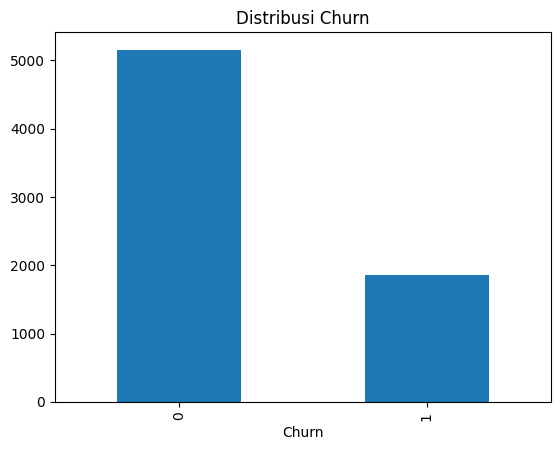

In [ ]:
import matplotlib.pyplot as plt

churn_data['Churn'].value_counts().plot(kind='bar')
plt.title('Distribusi Churn')
plt.show()

###Dataset menunjukkan class imbalance dimana pelanggan yang tidak churn jauh lebih dominan dibanding churn. Hal ini perlu diperhatikan pada tahap modeling agar model tidak bias ke kelas mayoritas.


###Distribusi Vitur Numerik = 1.tenure 2. MonthlyCharges 3. Total Charges


#### DVN 'tenure'

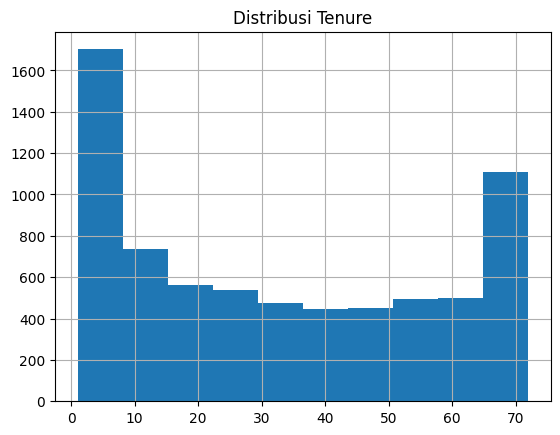

In [ ]:
#untuk tenure
churn_data['tenure'].hist()
plt.title('Distribusi Tenure')
plt.show()

####Dari pola yang ditampilkan distribusi biaa dilihat bahwa tenure menunjukkan pola tidak merata (bimodal/cenderung U-shape), dimana terdapat banyak pelanggan dengan tenure sangat rendah (pelanggan baru) dan juga cukup banyak pelanggan dengan tenure tinggi (pelanggan lama).

####Beberaoa kemungkinan:

####1. Perusahaan terus mendapatkan pelanggan baru (tenure rendah tinggi jumlahnya)

####2. Terdapat kelompok pelanggan loyal dengan masa berlangganan panjang

####3. Periode awal berlangganan kemungkinan merupakan fase kritis yang perlu dianalisis lebih lanjut terhadap churn

####4. Distribusi yang tidak normal ini juga menunjukkan bahwa tenure berpotensi menjadi fitur penting dalam memprediksi churn.

####DVN 'MonthlyCharges'

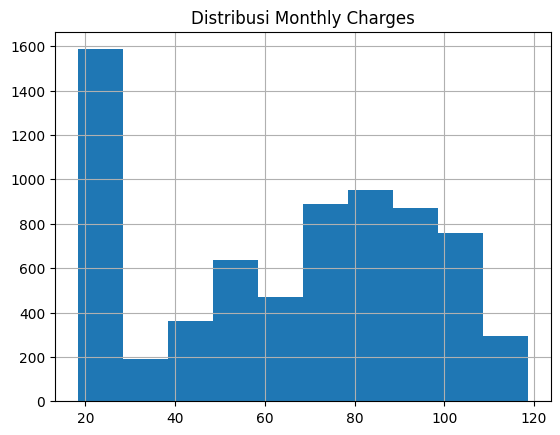

In [ ]:
#untuk MonthlyCharges
churn_data['MonthlyCharges'].hist()
plt.title('Distribusi Monthly Charges')
plt.show()

####Distribusi Monthly Charges menunjukkan pola Bimodal (memiliki dua puncak utama), di mana konsentrasi pelanggan terbesar berada pada rentang harga rendah (sekitar 20) dan puncak kedua berada pada rentang harga tinggi (sekitar 70–100).

####Ini mengindisasikan beberap hal:

####1. Segmentasi Pelanggan yang Jelas: Terdapat kelompok pelanggan "Basic" yang kemungkinan besar hanya mengambil layanan minimal (telepon saja) dan kelompok "Premium" yang mengambil paket lengkap (Fiber optic/TV).

####2. Kesenjangan Harga: Sedikitnya jumlah pelanggan pada rentang harga menengah (40–60) menunjukkan bahwa penawaran paket perusahaan cenderung terpolarisasi ke harga murah atau harga mahal.

####3. Risiko Churn pada Segmen Premium: Konsentrasi pelanggan yang cukup besar di angka 70–100 menjadi area krusial, karena biaya yang tinggi seringkali menjadi pemicu utama pelanggan untuk mencari kompetitor.

####4. Target Strategi Retensi: Perusahaan perlu menganalisis lebih dalam apakah tingginya biaya bulanan pada puncak kedua sebanding dengan kepuasan layanan guna mencegah kehilangan pelanggan bernilai tinggi (high-value customers).

####DVN 'TotalCharges'

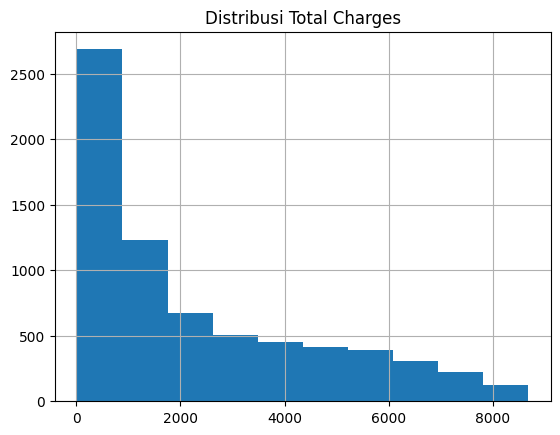

In [ ]:
#untuk TotalCharges
churn_data['TotalCharges'].hist()
plt.title('Distribusi Total Charges')
plt.show()

####Distribusi Total Charges menunjukkan pola Positive Skew (miring ke kanan), di mana frekuensi pelanggan menurun seiring bertambahnya jumlah total biaya yang dibayarkan.

####Hal ini bisa ditarik kemungkinan:

####1. Banyaknya Pelanggan Baru: Tingginya jumlah pelanggan di rentang 0-2000 menunjukkan bahwa basis data didominasi oleh pelanggan dengan masa langganan yang masih singkat (low tenure).

####2. Adanya Attrition (Pengurangan): Penurunan drastis pada grafik seiring meningkatnya biaya total mengindikasikan banyak pelanggan yang berhenti berlangganan sebelum mencapai total pembayaran yang tinggi.

####3. Kelompok Pelanggan Loyal: Sebagian kecil pelanggan yang mencapai angka 6000-8000 adalah aset berharga (pelanggan setia jangka panjang) yang perlu dipertahankan.

####4. Kaitan dengan Tenure: Distribusi ini sangat berkorelasi dengan lama berlangganan; semakin lama pelanggan bertahan, semakin besar kontribusi pendapatan (Total Charges) mereka bagi perusahaan.

###Distribusi Fitur Kategorikal

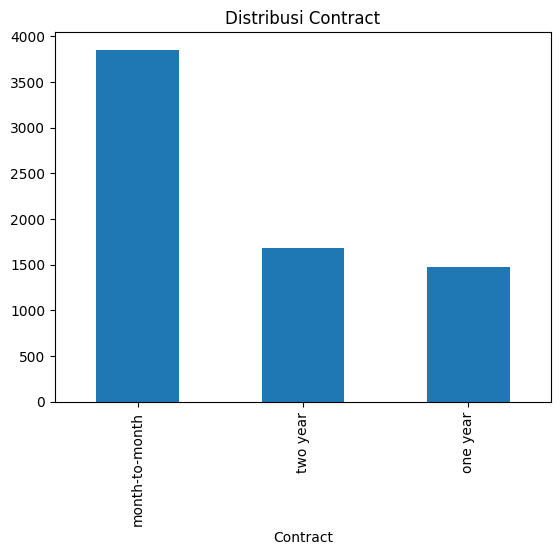

In [ ]:
churn_data['Contract'].value_counts().plot(kind='bar')
plt.title('Distribusi Contract')
plt.show()

####Dari visualisasi ini, ada beberapa hal yang bisa disimpulkan:

####1. Risiko Churn (Berhenti Berlangganan): Kontrak month-to-month memiliki jumlah yang sangat tinggi. Dalam analisis data, tipe kontrak ini biasanya memiliki risiko churn yang lebih besar karena pelanggan bisa berhenti kapan saja tanpa denda besar.

####2. Loyalitas: Pelanggan dengan kontrak Two year cukup signifikan, yang menunjukkan adanya segmen pelanggan loyal yang bersedia mengunci layanan dalam waktu lama.

####3. Strategi Pemasaran: Perusahaan mungkin perlu memberikan insentif lebih (seperti diskon atau fitur tambahan) untuk mendorong pelanggan month-to-month beralih ke kontrak satu atau dua tahun agar retensi pelanggan lebih stabil.

##3.2 Bivariate Analysis

###Menganalisis Hubungan Churn dengan Fitur Kategorikal

---



####Contract vs Churn



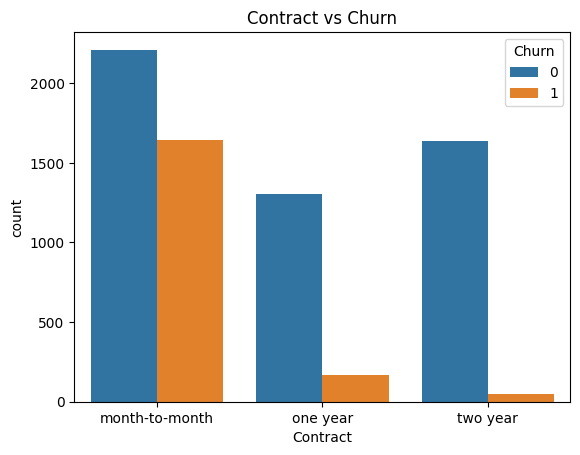

In [ ]:
###Hubungan Contract dengan Churn
import seaborn as sns

sns.countplot(x='Contract', hue='Churn', data=churn_data)
plt.title('Contract vs Churn')
plt.show()

####1. Pola Churn Berdasarkan Kontrak
####- month-to-month (Kontrak Bulanan): Memiliki jumlah pelanggan yang paling banyak berhenti (Churn = 1) dibandingkan jenis kontrak lainnya. Batang oranye di kategori ini sangat tinggi (lebih dari 1.500 pelanggan).

####- One year (Kontrak 1 Tahun): Tingkat churn menurun drastis. Hanya sebagian kecil pelanggan yang berhenti dibandingkan mereka yang tetap bertahan.

####- Two year (Kontrak 2 Tahun): Memiliki tingkat churn paling rendah. Hampir seluruh pelanggan dengan kontrak dua tahun tetap setia (Churn = 0), dan yang berhenti sangat sedikit (hampir tidak terlihat di grafik).

####2. Kesimpulan Utama
####da korelasi negatif yang sangat kuat antara durasi kontrak dan kemungkinan churn: Semakin lama durasi kontrak, semakin rendah kemungkinan pelanggan untuk berhenti.

####3. Rekomendasi Bisnis
####- Berdasarkan data ini, strategi yang bisa diambil perusahaan adalah:

####- Insentif Migrasi: Memberikan promo atau diskon khusus bagi pelanggan bulanan agar mereka mau berpindah ke kontrak minimal 1 tahun.

####- Early Warning: Memfokuskan tim Customer Sucess untuk memantau pelanggan bulanan, karena mereka adalah segmen yang paling rentan pindah ke kompetitor.

####- Retention Program: Memberikan apresiasi (seperti poin atau fitur tambahan) kepada pemegang kontrak 2 tahun agar mereka tetap memperpanjang kontraknya saat masa berlakunya habis.

####TechSupport vs Churn

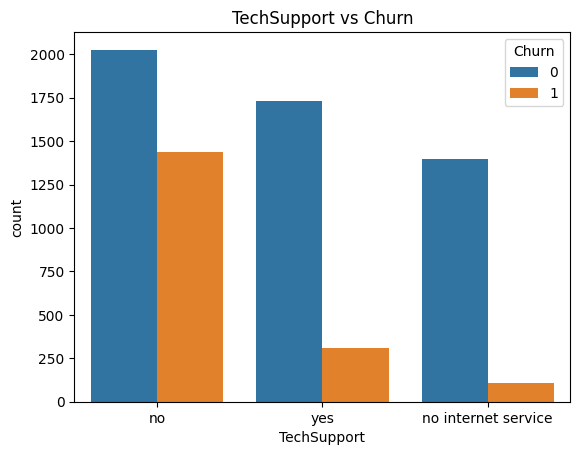

In [ ]:
sns.countplot(x='TechSupport', hue='Churn', data=churn_data)
plt.title('TechSupport vs Churn')
plt.show()

####Grafik Contract vs Churn memperjelas temuan dari distribusi sebelumnya:

####1. Risiko Kritikal pada Kontrak Bulanan: Pelanggan dengan kontrak month-to-month memiliki jumlah churn (batang oranye) yang sangat tinggi, hampir mendekati jumlah pelanggan yang bertahan. Ini menunjukkan bahwa kontrak jangka pendek adalah prediktor kuat bagi pelanggan yang akan berhenti.

####2. Stabilitas Kontrak Jangka Panjang: Pada kontrak One year dan Two year, jumlah pelanggan yang churn jauh lebih sedikit dibandingkan yang bertahan. Kontrak dua tahun menunjukkan tingkat loyalitas tertinggi dengan angka churn yang sangat minimal.

####OnlineSecurity vs Churn

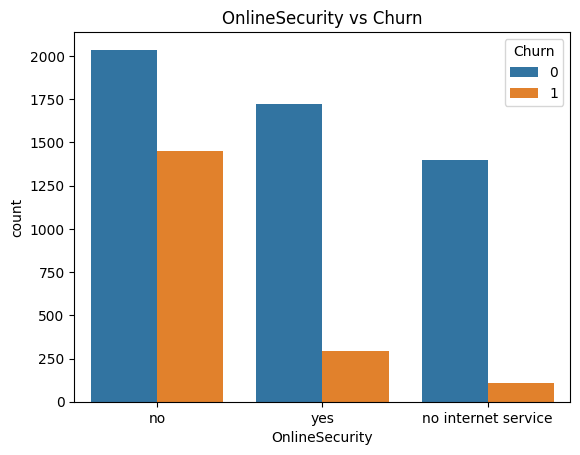

In [ ]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=churn_data)
plt.title('OnlineSecurity vs Churn')
plt.show()

####Insight OnlineSecurity vs Churn:
####1. Risiko Tinggi pada Ketidakhadiran Layanan: Pelanggan yang tidak memiliki Online Security (no) menunjukkan jumlah churn (batang oranye) yang sangat masif. Ini mengindikasikan bahwa tanpa perlindungan keamanan digital, pelanggan merasa kurang memiliki "ikatan" atau nilai tambah, sehingga jauh lebih mudah untuk berpindah ke kompetitor.

####2. Keamanan sebagai Jangkar Retensi: Pada pelanggan yang mengaktifkan Online Security (yes), jumlah churn sangat minimal dibandingkan dengan pelanggan yang bertahan. Hal ini membuktikan bahwa layanan keamanan berfungsi sebagai retention tool yang efektif; pelanggan yang merasa aman dengan layanan tersebut cenderung jauh lebih loyal.

####InternetService vs Churn

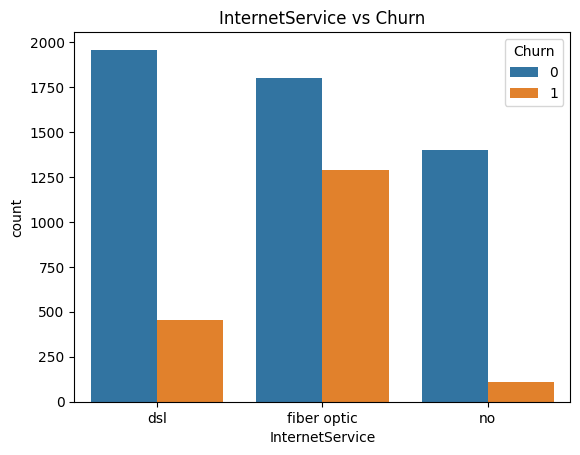

In [ ]:
sns.countplot(x='InternetService', hue='Churn', data=churn_data)
plt.title('InternetService vs Churn')
plt.show()

####Insight InternetService vs Churn:
####1. Titik Kritis pada Layanan Fiber Optic: Pelanggan yang menggunakan layanan Fiber optic memiliki proporsi churn (batang oranye) yang sangat mengkhawatirkan. Meskipun teknologi ini menawarkan kecepatan tinggi, jumlah pelanggan yang berhenti hampir mendekati jumlah pelanggan yang bertahan, yang menandakan adanya isu serius pada kepuasan atau harga di segmen ini.

####2.Stabilitas pada Layanan DSL dan Tanpa Internet:

#### -DSL: Pelanggan dengan layanan DSL menunjukkan tingkat loyalitas yang jauh lebih stabil, di mana jumlah yang bertahan (batang biru) mendominasi secara signifikan.

#### -no Internet: Segmen tanpa layanan internet memiliki angka churn paling rendah. Ini menunjukkan bahwa pelanggan paket komunikasi dasar adalah kelompok yang paling kecil kemungkinannya untuk meninggalkan layanan.

####PaymentMethod vs Churn

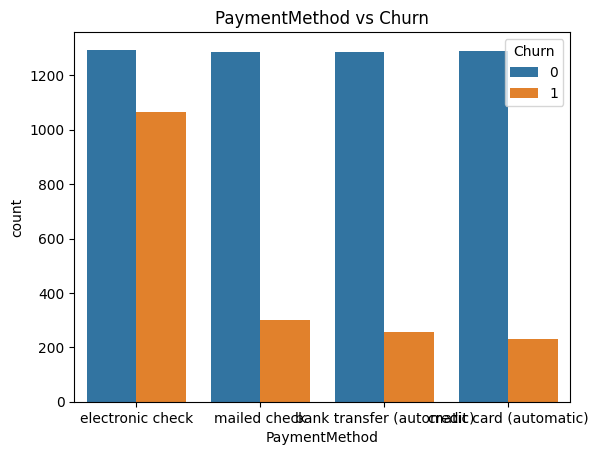

In [ ]:
sns.countplot(x='PaymentMethod', hue='Churn', data=churn_data)
plt.title('PaymentMethod vs Churn')
plt.show()

####Insight PaymentMethod vs Churn:
####1. Anomali pada Electronic Check: Metode pembayaran Electronic check menunjukkan risiko churn yang sangat ekstrem, di mana jumlah pelanggan yang berhenti (batang oranye) melebihi 1.000 pelanggan. Angka ini jauh lebih tinggi dibandingkan metode pembayaran lainnya, yang menunjukkan adanya korelasi kuat antara metode pembayaran manual/non-otomatis dengan keputusan untuk berhenti berlangganan.

####2. Efektivitas Sistem Otomatis: Pelanggan yang menggunakan metode pembayaran otomatis, baik melalui Bank transfer (automatic) maupun Credit card (automatic), memiliki tingkat churn yang sangat rendah (di bawah 300 pelanggan). Sistem pembayaran otomatis terbukti menjadi faktor pendukung stabilitas basis pelanggan karena mengurangi hambatan transaksi bulanan.

####tenure vs Churn (boxplot)

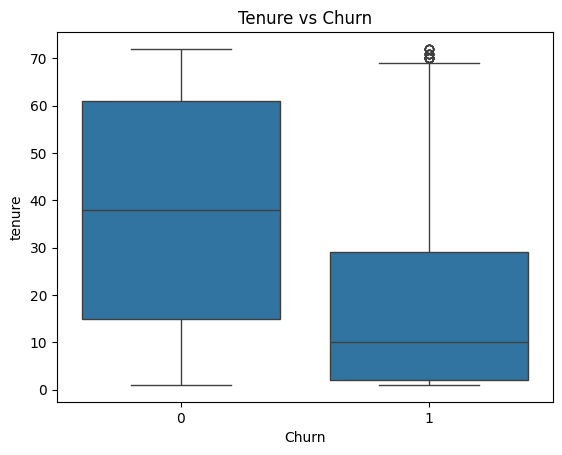

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=churn_data)
plt.title('Tenure vs Churn')
plt.show()

####Insight Tenure vs Churn:

1. Tenure rendah sebagai indikasi awal churn: Pelanggan yang churn memiliki median tenure sekitar ~ 10 bulan, jauh di bawah pelanggan yang bertahan (~ 38 bulan). Ini menunjukkan bahwa periode awal berlangganan merupakan fase paling rentan terhadap churn.

2.Loyalitas meningkat seiring waktu: Pelanggan yang tidak churn memiliki rentang tenure yang luas dan cenderung lebih tinggi. Semakin lama pelanggan bertahan, semakin besar kemungkinan mereka untuk tetap loyal.

3.Outlier pada churn dengan tenure tinggi: Terdapat beberapa pelanggan dengan tenure tinggi yang tetap churn. Hal ini menunjukkan bahwa faktor lain di luar lama berlangganan juga berpengaruh terhadap keputusan pelanggan.

###Churn vs Numerik

####tenure vs Churn (boxplot)

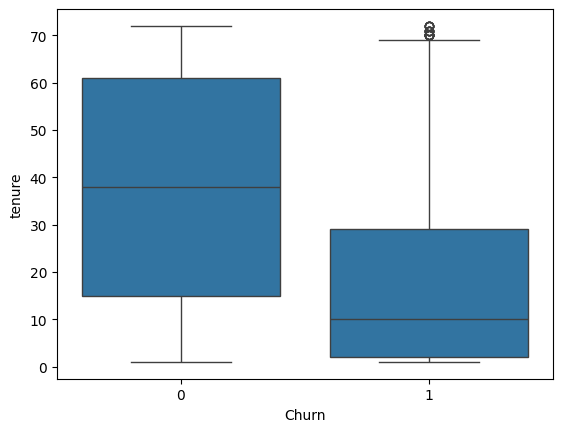

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=churn_data)
plt.show()

####Insight Tenure vs Churn:

1. Tenure rendah lebih rentan churn: Pelanggan yang churn memiliki median tenure sekitar ~ 10 bulan, jauh lebih rendah dibandingkan yang tidak churn (~ 38 bulan). Ini menunjukkan bahwa pelanggan baru lebih berisiko untuk berhenti berlangganan.

2. Pelanggan lama cenderung lebih stabil: Kelompok tidak churn memiliki rentang tenure yang lebih luas dan cenderung berada di level lebih tinggi. Semakin lama pelanggan bertahan, semakin kecil kemungkinan mereka untuk churn.

3.Tenure tinggi tidak menjamin loyalitas: Terdapat beberapa pelanggan dengan tenure tinggi yang tetap churn. Hal ini menandakan bahwa selain durasi berlangganan, ada faktor lain yang memengaruhi keputusan pelanggan.

MonthlyCharges vs Churn (boxplot)

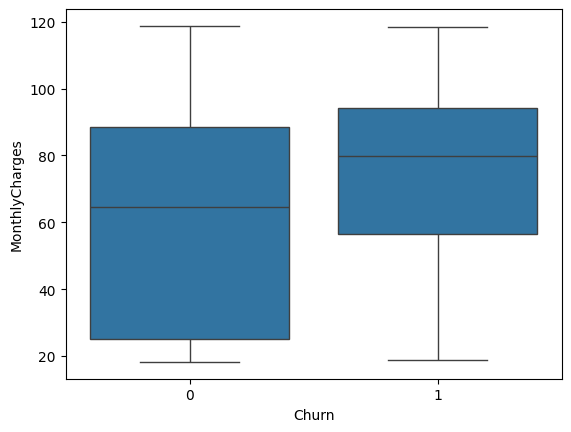

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn_data)
plt.show()

####Insight MonthlyCharges vs Churn:

1. Tagihan tinggi sebagai pemicu churn:Pelanggan yang churn cenderung memiliki tagihan bulanan lebih tinggi (sekitar ~ 80) dibandingkan pelanggan yang tidak churn (~ 65). Hal ini menunjukkan bahwa semakin tinggi biaya yang dikeluarkan, semakin besar kemungkinan pelanggan untuk berhenti berlangganan.

2. Sebaran tagihan churn lebih terkonsentrasi: Pelanggan churn umumnya berada pada rentang tagihan menengah ke atas (±60–95), dengan variasi yang tidak terlalu lebar. Sebaliknya, pelanggan yang tidak churn memiliki distribusi tagihan yang lebih beragam.

3. Tagihan rendah lebih stabil: Pelanggan dengan tagihan rendah cenderung lebih loyal. Ini mengindikasikan bahwa paket dengan harga terjangkau dapat membantu menekan tingkat churn.

####TotalCharges vs Churn(boxplot)

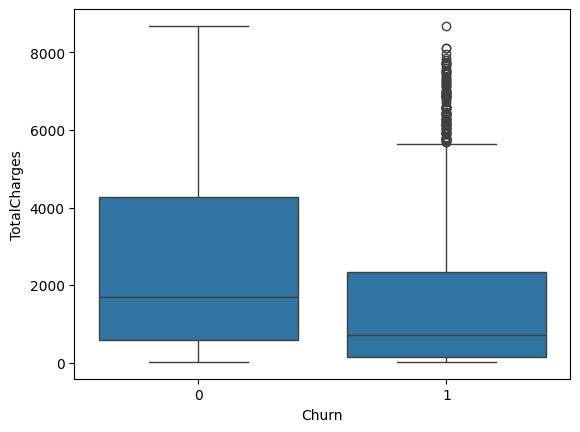

In [ ]:
sns.boxplot(x='Churn', y='TotalCharges', data=churn_data)
plt.show()

####Insight TotalCharges vs Churn:

1. TotalCharges rendah pada pelanggan churn: Pelanggan yang churn memiliki median TotalCharges sekitar ~ 700, lebih rendah dibandingkan pelanggan yang tidak churn (~ 1.700). Hal ini menunjukkan bahwa pelanggan yang berhenti umumnya belum lama berlangganan sehingga kontribusi totalnya masih kecil. Kondisi ini memperlihatkan bahwa perusahaan belum sempat memaksimalkan nilai pelanggan sebelum mereka keluar.

2. Sebaran lebih luas pada pelanggan tidak churn: Kelompok tidak churn memiliki rentang TotalCharges yang lebih besar, mencerminkan variasi pelanggan dari yang baru hingga yang sudah lama berlangganan dengan akumulasi tagihan tinggi. Sementara itu, pelanggan churn cenderung terkonsentrasi pada nilai yang lebih rendah. Pola ini mengindikasikan bahwa pelanggan yang mampu bertahan lebih lama akan memberikan kontribusi finansial yang jauh lebih signifikan.

3. Adanya churn pada pelanggan bernilai tinggi: Terdapat beberapa pelanggan dengan TotalCharges tinggi yang tetap churn. Hal ini mengindikasikan bahwa selain lamanya berlangganan dan nilai transaksi, terdapat faktor lain yang memengaruhi keputusan pelanggan. Fenomena ini penting diperhatikan karena kehilangan pelanggan dengan nilai tinggi dapat berdampak langsung pada penurunan pendapatan perusahaan.

##3.3 Correlation Numeric

####Melihat apakah ada hubungan kuat antar variabel numerik (multicollinearity & insight pola)

In [ ]:
churn_data[['tenure','MonthlyCharges','TotalCharges']].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.244194,0.825293
MonthlyCharges,0.244194,1.000000,0.650540
TotalCharges,0.825293,0.650540,1.000000


####Menampilkan visual dari tabel korelasi

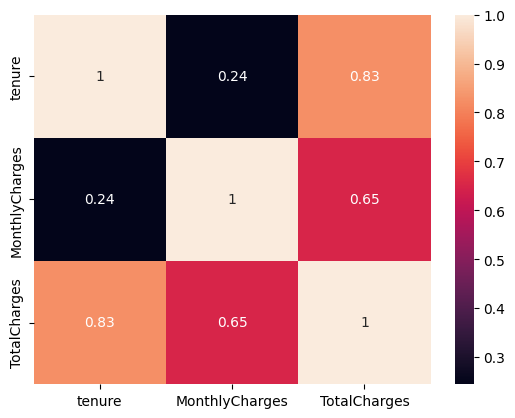

In [ ]:
sns.heatmap(
    churn_data[['tenure','MonthlyCharges','TotalCharges']].corr(),
    annot=True
)
plt.show()

#### Korelasi antara Tenure, Monthly Charges, dan Total Charges

Heatmap korelasi menunjukkan hubungan antara tiga variabel numerik utama dalam dataset: **tenure**, **MonthlyCharges**, dan **TotalCharges**.

1. Hubungan kuat antara tenure dan TotalCharges: Nilai korelasi sebesar 0.83 menunjukkan bahwa semakin lama pelanggan berlangganan, semakin besar total biaya yang dibayarkan. Hal ini wajar karena TotalCharges merupakan akumulasi dari pembayaran selama periode berlangganan.

2. Pengaruh MonthlyCharges terhadap TotalCharges: Korelasi sebesar 0.65 menunjukkan hubungan yang cukup kuat, di mana pelanggan dengan biaya bulanan lebih tinggi cenderung memiliki total pembayaran yang lebih besar. Namun, pengaruhnya tidak sekuat faktor lamanya berlangganan.

3. Hubungan lemah antara tenure dan MonthlyCharges: Nilai korelasi yang rendah (0.24) menunjukkan bahwa durasi berlangganan tidak terlalu berkaitan dengan besarnya biaya bulanan. Pelanggan baru maupun lama dapat berada pada berbagai tingkat harga layanan.

4. TotalCharges lebih dipengaruhi oleh durasi berlangganan: Secara keseluruhan, TotalCharges lebih banyak dipengaruhi oleh tenure dibandingkan MonthlyCharges. Ini menegaskan bahwa lamanya pelanggan bertahan merupakan faktor utama dalam menentukan nilai total yang dihasilkan.


###Churn Rate per Kategori

In [ ]:
churn_data.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
month-to-month  0        0.573579
                1        0.426421
one year        0        0.887228
                1        0.112772
two year        0        0.971513
                1        0.028487
Name: proportion, dtype: float64

#### Churn Rate berdasarkan Jenis Contract

Analisis menunjukkan bahwa jenis kontrak memiliki hubungan yang kuat dengan tingkat churn pelanggan.

Pelanggan dengan **month-to-month contract** memiliki churn rate tertinggi, yaitu sekitar **42.6%**. Artinya hampir setengah pelanggan pada segmen ini akhirnya berhenti berlangganan. Hal ini kemungkinan disebabkan oleh fleksibilitas kontrak bulanan yang tidak mengikat, sehingga pelanggan dapat dengan mudah berpindah layanan tanpa konsekuensi jangka panjang.

Sebaliknya, churn rate menurun secara signifikan pada kontrak dengan durasi lebih panjang. Pada **one-year contract**, churn rate turun menjadi sekitar **11.3%**, sementara pada **two-year contract** hanya sekitar **2.8%**. Pola ini menunjukkan bahwa semakin panjang komitmen kontrak pelanggan, semakin rendah kemungkinan mereka untuk churn.

Perbedaan yang cukup besar antara **month-to-month** dan **two-year contract** menunjukkan adanya peluang bagi perusahaan untuk meningkatkan retensi pelanggan. Salah satu strategi yang dapat dipertimbangkan adalah mendorong pelanggan dengan kontrak bulanan untuk beralih ke kontrak jangka panjang melalui insentif seperti diskon, bundling layanan, atau penawaran upgrade kontrak.


##3.4 Class Imbalance Check

=== Distribusi Churn ===
No Churn: 5153 (73.5%)
Churn: 1857 (26.5%)


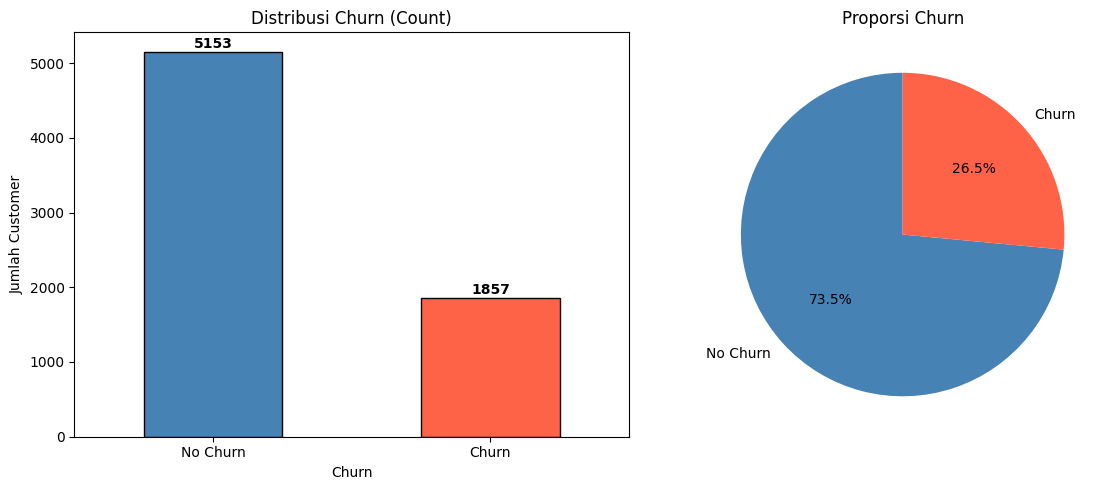

In [ ]:
# Mapping 0/1 ke label yang readable
churn_map = {0: 'No Churn', 1: 'Churn'}
churn_counts = churn_data['Churn'].map(churn_map).value_counts()
churn_percent = churn_data['Churn'].map(churn_map).value_counts(normalize=True) * 100

print("=== Distribusi Churn ===")
for val, count, pct in zip(churn_counts.index, churn_counts, churn_percent):
    print(f"{val}: {count} ({pct:.1f}%)")

# Visualisasi (sama seperti sebelumnya)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribusi Churn (Count)')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Jumlah Customer')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporsi Churn')

plt.tight_layout()
plt.show()

#### Insight Class Imbalance Analysis

1. Terjadi ketidakseimbangan kelas: Dari distribusi data, terlihat bahwa sekitar 73% pelanggan tidak churn, sedangkan hanya 27% yang churn. Artinya, kasus churn memang lebih sedikit dibandingkan yang bertahan.

2. Dampak terhadap performa model: Kondisi ini bisa membuat model lebih “condong” ke kelas mayoritas. Jadi walaupun akurasi terlihat bagus, belum tentu model benar-benar peka dalam mendeteksi pelanggan yang churn.

3. Perlu penanganan saat modeling: Supaya hasilnya lebih seimbang, biasanya digunakan teknik seperti SMOTE untuk menambah data pada kelas minoritas, atau pengaturan class_weight='balanced' agar model tidak terlalu bias.



##3.5 Outlier Analysis

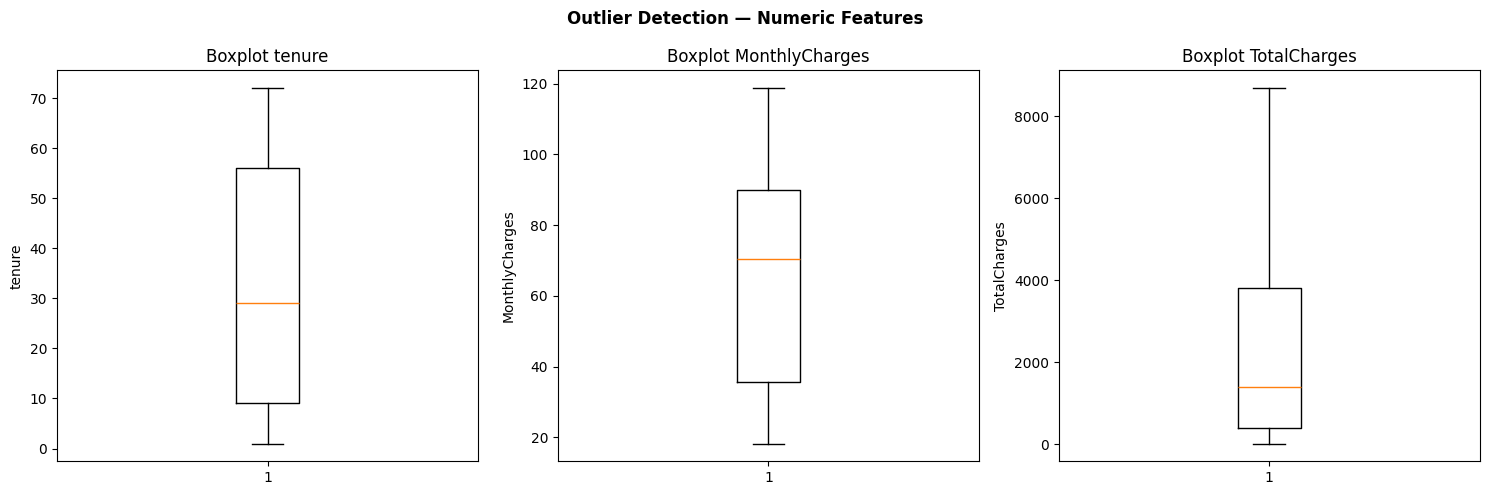

Jumlah Outlier per Kolom (IQR Method)
tenure: 0 outlier (lower=-61.50, upper=126.50)
MonthlyCharges: 0 outlier (lower=-45.48, upper=171.12)
TotalCharges: 0 outlier (lower=-4690.98, upper=8907.12)


In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    axes[i].boxplot(churn_data[col].dropna())
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

# IQR Method — Menghitung jumlah outlier per kolom
print("Jumlah Outlier per Kolom (IQR Method)")
for col in num_cols:
    Q1 = churn_data[col].quantile(0.25)
    Q3 = churn_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = churn_data[(churn_data[col] < lower) | (churn_data[col] > upper)]
    print(f"{col}: {len(outliers)} outlier (lower={lower:.2f}, upper={upper:.2f})")


### Insight Outlier Analysis

Deteksi outlier dilakukan pakai boxplot dan IQR method di kolom numerik.

1. tenure: distribusinya cukup merata dari 0 sampai 72 bulan,
median sekitar 29 bulan. Tidak ada outlier, customer tersebar
dari yang baru sampai yang udah lama langganan.

2. MonthlyCharges: median sekitar 70, boxnya agak condong ke atas
yang berarti lebih banyak customer dengan tagihan menengah ke atas.
Tidak ada outlier.

3. TotalCharges: ini yang menarik, mediannya rendah (~1500) padahal
upper boundnya sampai 8907. Distribusinya skewed ke kanan karena
banyak customer baru yang tenure-nya masih rendah jadi total tagihannya
juga kecil. Tapi tetap tidak ada outlier.

Kesimpulan: tidak perlu handling outlier untuk ketiga kolom ini.

##3.6 Multivariate Analysis

###Scatter Plot (tenure + MonthlyCharges → Churn)

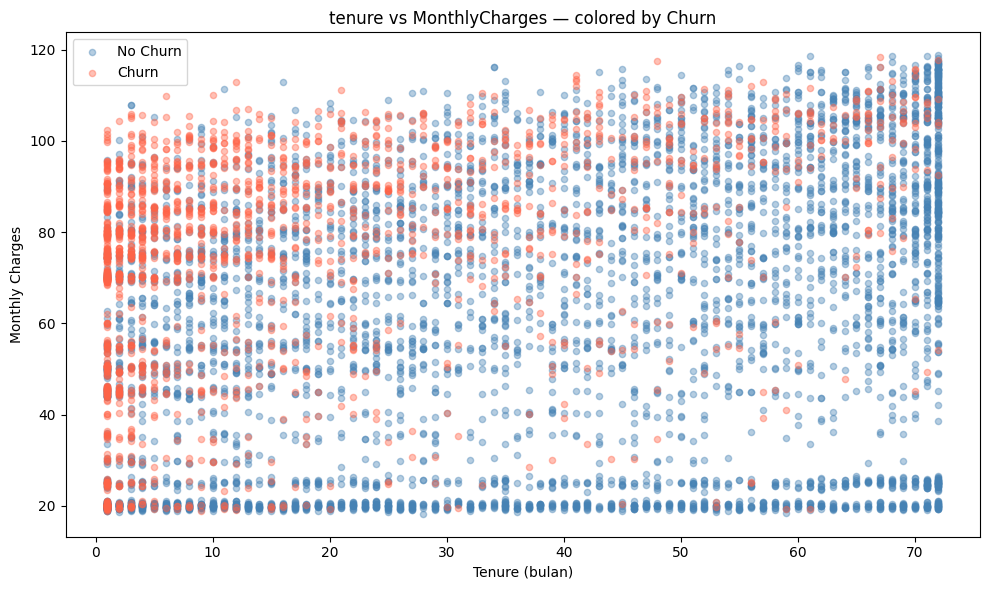

In [ ]:
# Multivariate Analysis
# tenure + MonthlyCharges → Churn

fig, ax = plt.subplots(figsize=(10, 6))

colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'No Churn', 1: 'Churn'}

for churn_val in [0, 1]:
    subset = churn_data[churn_data['Churn'] == churn_val]
    ax.scatter(subset['tenure'], subset['MonthlyCharges'],
               c=colors[churn_val], label=labels[churn_val],
               alpha=0.4, s=20)

ax.set_title('tenure vs MonthlyCharges — colored by Churn')
ax.set_xlabel('Tenure (bulan)')
ax.set_ylabel('Monthly Charges')
ax.legend()
plt.tight_layout()
plt.show()

####tenure vs MonthlyCharges (colored by Churn)
Dari scatter plot terlihat 3 pola menarik:
1. Customer churn (merah) sangat padat di tenure rendah (0-20 bulan)
  dengan monthly charges tinggi, customer baru yang bayar mahal
  paling rentan churn
2. Semakin tinggi tenure, titik merah makin jarang, customer lama
  cenderung lebih loyal
3. Customer dengan monthly charges rendah (~20-25) hampir tidak churn
  di semua level tenure

###Heatmap (Contract + InternetService → Churn rate)

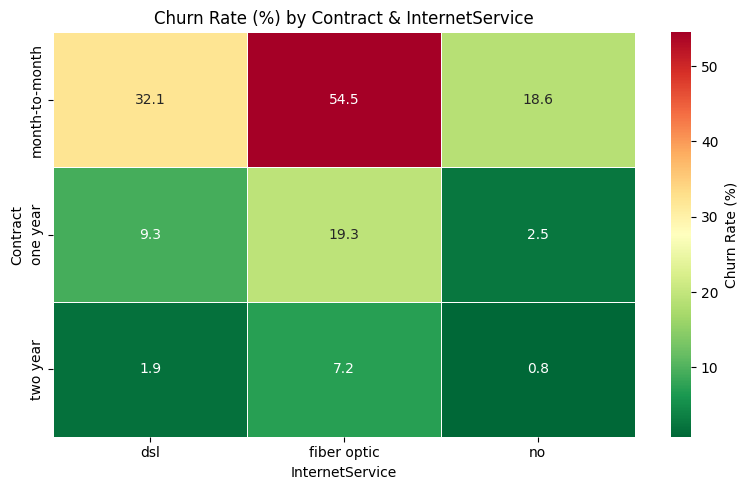

In [ ]:
#Contract + InternetService → Churn Rate

pivot = churn_data.groupby(['Contract', 'InternetService'])['Churn'].mean() * 100
pivot = pivot.unstack()

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'})
plt.title('Churn Rate (%) by Contract & InternetService')
plt.tight_layout()
plt.show()

#### Contract + Internet Service → Churn Rate

Berdasarkan heatmap yang dibuat, terlihat bahwa kombinasi **month-to-month contract** dan **fiber optic internet service** memiliki churn rate yang sangat tinggi, yaitu sekitar **54.5%**. Artinya, lebih dari setengah pelanggan pada segmen ini akhirnya berhenti menggunakan layanan.

Jika dibandingkan dengan jenis layanan internet lainnya, **fiber optic** cenderung memiliki churn rate yang lebih tinggi pada hampir semua tipe contract. Salah satu kemungkinan penyebabnya adalah harga layanan fiber optic yang relatif lebih mahal, sehingga pelanggan menjadi lebih sensitif terhadap nilai layanan yang mereka terima dan lebih mudah berpindah ke kompetitor.

Namun, ketika pelanggan menggunakan **two-year contract**, churn rate turun secara signifikan. Bahkan pada layanan fiber optic, churn dapat turun dari **54.5% menjadi sekitar 7.2%** ketika pelanggan beralih ke kontrak jangka panjang.

Temuan ini menunjukkan bahwa **jenis kontrak kemungkinan memiliki pengaruh yang lebih besar terhadap churn dibandingkan jenis layanan internet itu sendiri**.

**Business Recommendation:**  
Perusahaan dapat memprioritaskan pelanggan dengan **month-to-month contract yang menggunakan fiber optic**, karena segmen ini memiliki risiko churn paling tinggi. Memberikan insentif atau promosi untuk mendorong pelanggan berpindah ke **kontrak jangka panjang** berpotensi membantu menurunkan tingkat churn secara signifikan.

##4. Feature Engineeirng and Preprocesing

###4.1 Categorical Encoding

In [ ]:
# Categorical Encoding — Pre-check

cat_cols = churn_data.select_dtypes(include='object').columns.tolist()
print("Kolom Kategorikal")
for col in cat_cols:
    print(f"\n[{col}] — {churn_data[col].nunique()} unique values:")
    print(churn_data[col].unique())

Kolom Kategorikal

[gender] — 2 unique values:
['female' 'male']

[Partner] — 2 unique values:
['yes' 'no']

[Dependents] — 2 unique values:
['no' 'yes']

[PhoneService] — 2 unique values:
['no' 'yes']

[MultipleLines] — 3 unique values:
['no phone service' 'no' 'yes']

[InternetService] — 3 unique values:
['dsl' 'fiber optic' 'no']

[OnlineSecurity] — 3 unique values:
['no' 'yes' 'no internet service']

[OnlineBackup] — 3 unique values:
['yes' 'no' 'no internet service']

[DeviceProtection] — 3 unique values:
['no' 'yes' 'no internet service']

[TechSupport] — 3 unique values:
['no' 'yes' 'no internet service']

[StreamingTV] — 3 unique values:
['no' 'yes' 'no internet service']

[StreamingMovies] — 3 unique values:
['no' 'yes' 'no internet service']

[Contract] — 3 unique values:
['month-to-month' 'one year' 'two year']

[PaperlessBilling] — 2 unique values:
['yes' 'no']

[PaymentMethod] — 4 unique values:
['electronic check' 'mailed check' 'bank transfer (automatic)'
 'credit card (

####Binary Mapping (Yes/No Columns)

In [ ]:
# Binary Mapping (Yes/No columns)

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

binary_map = {'yes': 1, 'no': 0, 'female': 0, 'male': 1}

for col in binary_cols:
    churn_data[col] = churn_data[col].map(binary_map)

print("Binary Mapping Done")
print(churn_data[binary_cols].head())

Binary Mapping Done
   gender  Partner  Dependents  PhoneService  PaperlessBilling
0       0        1           0             0                 1
1       1        0           0             1                 0
2       1        0           0             1                 1
3       1        0           0             0                 0
4       0        0           0             1                 1


####Binary Mapping (Yes/No/No Internet Service Columns)

In [ ]:
# Binary Mapping (Yes/No/No internet service columns)


multi_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

multi_map = {'no': 0, 'yes': 1, 'no internet service': 2, 'no phone service': 2}

for col in multi_cols:
    churn_data[col] = churn_data[col].map(multi_map)

print("Multi Mapping Done")
print(churn_data[multi_cols].head())

Multi Mapping Done
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              2               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   
3              2               1             0                 1            1   
4              0               0             0                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  
3            0                0  
4            0                0  


####Ordinal Encoding (Contract)

In [ ]:
# Ordinal Encoding — Contract

contract_map = {
    'month-to-month': 0,
    'one year': 1,
    'two year': 2
}

churn_data['Contract'] = churn_data['Contract'].map(contract_map)

print("Ordinal Encoding Done")
print(churn_data['Contract'].value_counts())

Ordinal Encoding Done
Contract
0    3853
2    1685
1    1472
Name: count, dtype: int64


####One-Hot Encoding

In [ ]:
# One Hot Encoding — InternetService & PaymentMethod


churn_data = pd.get_dummies(churn_data,
                            columns=['InternetService', 'PaymentMethod'],
                            drop_first=False)

print("One Hot Encoding Done")
print(churn_data.shape)
print(churn_data.columns.tolist())

One Hot Encoding Done
(7010, 25)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_dsl', 'InternetService_fiber optic', 'InternetService_no', 'PaymentMethod_bank transfer (automatic)', 'PaymentMethod_credit card (automatic)', 'PaymentMethod_electronic check', 'PaymentMethod_mailed check']


####Validasi Hasil Encoding

In [ ]:
# Validasi Hasil Encoding

# Cek apakah masih ada kolom kategorikal (object) yang belum di-encode
remaining_cat = churn_data.select_dtypes(include='object').columns.tolist()

if len(remaining_cat) == 0:
    print("Semua kolom kategorikal sudah ter-encode")
else:
    print(f"Kolom yang belum di-encode: {remaining_cat}")

# Cek shape akhir
print(f"\nShape akhir: {churn_data.shape}")
print(f"\nDtype per kolom:")
print(churn_data.dtypes)

Semua kolom kategorikal sudah ter-encode

Shape akhir: (7010, 25)

Dtype per kolom:
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
Contract                                     int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int6

####Convert boolean columns ke integer

In [ ]:
# Convert bool columns ke int
bool_cols = churn_data.select_dtypes(include='bool').columns.tolist()
churn_data[bool_cols] = churn_data[bool_cols].astype(int)

print("Bool columns diubah ke int")
print(churn_data.dtypes)

Bool columns diubah ke int
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
Contract                                     int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_dsl                          int64
Inte

###4.2 Scalling and Normalization

In [ ]:
#Scaling & Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

churn_data[num_cols] = scaler.fit_transform(churn_data[num_cols])

print("Scaling Done")
print(churn_data[num_cols].describe().round(2))

Scaling Done
        tenure  MonthlyCharges  TotalCharges
count  7010.00         7010.00       7010.00
mean     -0.00           -0.00         -0.00
std       1.00            1.00          1.00
min      -1.29           -1.55         -1.00
25%      -0.96           -0.97         -0.83
50%      -0.14            0.18         -0.39
75%       0.96            0.83          0.67
max       1.61            1.79          2.82


###4.3 Handle Class Imbalance (SMOTE)

In [ ]:
#4c. Handle Class Imbalance — SMOTE

from imblearn.over_sampling import SMOTE

# Pisahkan fitur dan target
X = churn_data.drop('Churn', axis=1)
y = churn_data['Churn']

print("=== Sebelum SMOTE ===")
print(y.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nSetelah SMOTE")
print(y_resampled.value_counts())
print(f"\nShape X: {X_resampled.shape}")

=== Sebelum SMOTE ===
Churn
0    5153
1    1857
Name: count, dtype: int64

Setelah SMOTE
Churn
0    5153
1    5153
Name: count, dtype: int64

Shape X: (10306, 24)


### Feature Engineering & Preprocessing (Penjelasan)

Sebelum masuk ke modeling, ada beberapa hal yang perlu disiapkan
supaya data bisa dibaca sama model dengan benar.

**Categorical Encoding**
Kolom-kolom kategorikal dikonversi ke numerik karena model tidak
bisa baca teks. Strateginya dibagi jadi 3:
- Kolom Yes/No langsung di-map ke 0 dan 1
- Kolom Contract pakai ordinal encoding karena ada urutan yang jelas
  (month-to-month → one year → two year)
- InternetService dan PaymentMethod pakai One Hot Encoding karena
  tidak ada urutan antar kategorinya

**Scaling & Normalization**
Kolom numerik seperti tenure, MonthlyCharges, dan TotalCharges
punya skala yang sangat berbeda — tenure 0-72, MonthlyCharges 20-120,
TotalCharges bisa sampai 8000. Kalau dibiarkan, model akan bias ke
kolom dengan nilai besar. Makanya dipakai StandardScaler supaya
semua kolom punya skala yang sama (mean=0, std=1).

**Handle Class Imbalance — SMOTE**
Dataset aslinya tidak seimbang — 73% tidak churn, 27% churn.
Kalau dibiarkan, model akan cenderung prediksi "tidak churn" terus
karena itu jawaban yang paling sering benar. SMOTE dipakai untuk
generate data sintetis di kelas minoritas sampai jumlahnya seimbang,
dari 1857 naik ke 5153.

Setelah semua tahap ini, data sudah siap masuk ke modeling.

##5. Data Modelling

###5.1 Split Data

In [ ]:
# Split Data (Train/Test)

from sklearn.model_selection import train_test_split

X = X_resampled
y = y_resampled

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Split Data Done")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Split Data Done
X_train: (8244, 24)
X_test:  (2062, 24)
y_train: (8244,)
y_test:  (2062,)


#### Penjelasan Split Data (Train/Test)

Data dibagi jadi 2 bagian yaitu 80% untuk training, 20% untuk testing.
Logikanya simpel: model belajar dari data train, lalu diuji di data
test yang belum pernah dia lihat sebelumnya.

Beberapa parameter yang dipakai:
1. test_size=0.2, 20% data jadi test set, sisanya train
2. random_state=42, biar hasilnya reproducible, kalau dijalankan
  ulang hasilnya tetap sama
3. stratify=y, ini penting karena dataset kita punya kelas yang
  seimbang setelah SMOTE, stratify mastiin proporsi churn vs tidak
  churn di train dan test tetap sama

###5.2 Train Model

In [ ]:
#Train Model

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Inisialisasi model
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

#Train semua model
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} — trained")

Logistic Regression — trained
Random Forest — trained
XGBoost — trained


###5.3 Evaluasi Model

In [ ]:
# evaluasi semua model yang udah di-train
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

results = {}

for name, model in models.items():
    # prediksi di data test
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # simpan semua metrik ke dictionary
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    }

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

# lihat perbandingan semua model dalam satu tabel
results_df = pd.DataFrame(results).T.round(4)
print(results_df)


Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      1031
           1       0.78      0.82      0.80      1031

    accuracy                           0.79      2062
   macro avg       0.79      0.79      0.79      2062
weighted avg       0.79      0.79      0.79      2062


Random Forest
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1031
           1       0.82      0.86      0.84      1031

    accuracy                           0.83      2062
   macro avg       0.83      0.83      0.83      2062
weighted avg       0.83      0.83      0.83      2062


XGBoost
              precision    recall  f1-score   support

           0       0.84      0.81      0.83      1031
           1       0.82      0.85      0.83      1031

    accuracy                           0.83      2062
   macro avg       0.83      0.83      0.83      2062
weighted avg       0.83      

###5.4 Visualisasi Perbandungan Model

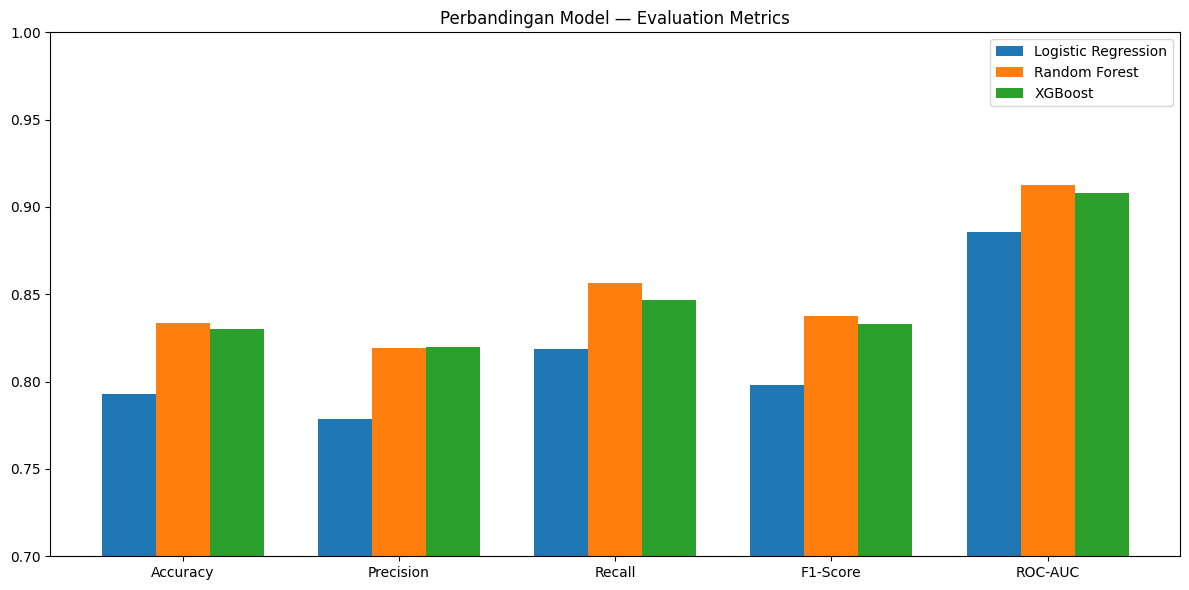

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (name, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i * width, row[metrics], width, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.0)
ax.set_title('Perbandingan Model — Evaluation Metrics')
ax.legend()
plt.tight_layout()
plt.show()

#### Model Comparison

Grafik perbandingan performa menunjukkan perbedaan kinerja antara tiga model klasifikas yang diuji, yaitu **Logistic Regression**, **Random Forest**, dan **XGBoost**.

Secara keseluruhan, **Random Forest** menunjukkan performa paling konsisten di hampir semua metrik evaluasi, dengan **accuracy sekitar 83%**, **recall 85%**, dan **ROC-AUC 0.91**. **XGBoost** memiliki performa yang sangat mendekati Random Forest, dengan selisih yang relatif kecil di hampir semua metrik. Sementara itu, **Logistic Regression** memiliki performa yang lebih rendah dibandingkan kedua model berbasis ensemble tersebut, meskipun masih berfungsi dengan baik sebagai model baseline untuk perbandingan.

Perbedaan performa paling terlihat pada metrik **ROC-AUC**, yang mengukur kemampuan model dalam membedakan pelanggan yang berpotensi churn dan yang tidak. Random Forest mencapai nilai **ROC-AUC sebesar 0.91**, sedikit lebih tinggi dibandingkan **XGBoost (0.90)** dan **Logistic Regression (0.88)**.

Selain itu, **recall menjadi metrik yang penting dalam konteks churn prediction**, karena kegagalan menseteksi pelanggan yang benar-benar berpotensi churn dapat berdampak langsung pada kehilangan pelanggan. Dalam metrik ini, Random Forest juga menunjukkan performa terbaik dengan **recall sebesar 85%**.

Berdasarkan hasil evaluasi tersebut, **Random Forest dipilih sebagai model final** karena memberikan keseimbangan performa terbaik di bervagai metrik evaluasi.


###5.5  Feature Importance



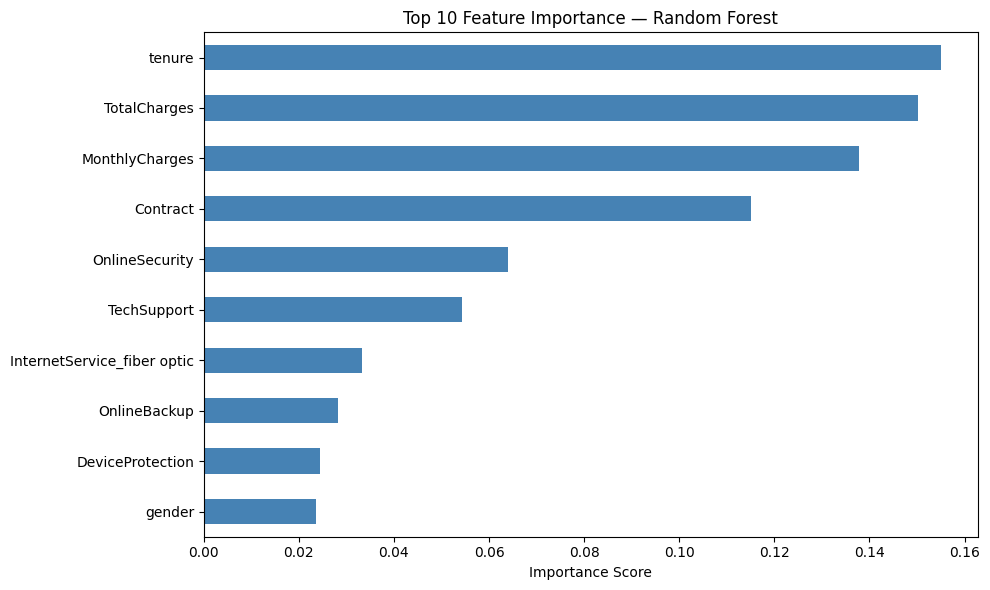

In [ ]:
# feature importance dari Random Forest (model terbaik)
feat_importance = pd.Series(
    models['Random Forest'].feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)[:10]

feat_importance.plot(kind='barh', figsize=(10, 6), color='steelblue')
plt.title('Top 10 Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#6. Kesimpulan

### Model Evaluation and Final Model Selection

Tiga algoritma klasifikasi diuji dalam proses modeling, yaitu **Logistic Regression**, **Random Forest**, dan **XGBoost**. Berdasarkan hasil evaluasi, **Random Forest** dipilih sebagai model finak karena menunjukkan performa paling stabil di berbagai metrik evaluasi, dengan **ROC-AUC sekitar 0.91** dan **recall sekitar 0.85**.

Dalam konteks prediksi churn, **recall menjadi metrik yang sangat penting**. Hal ini karena lebih baik model mengidentifikasi beberapa pelanggan loyal sebagai berisiko churn (false positive) dibandingkan gagal mendeteksi pelanggan yang benar-benar berpotensi churn. Dari perspektif bisnis, biaya melakukan upaya retensi biasanya jauh lebih kecil dibandingkan kehilangan pelanggan yang sudah ada.

Analisis feature importance dari model Randon Forest menunjukkan beberapa faktor utama yang paling berpengaruh terhadap kemungkinan churn, yaitu **tenure**, **TotalCharges**, **MonthlyCharges**, serta **jenis kontrak (Contract)** yang digunakan pelanggan.




### Business Insights and Recommendations

Berdasarkan hasil analisis eksploratif dan proses modeling, terdapat beberapa implikasi yang dapat dipertimbangkan oleh tim bisnis.

Pelanggan dengan **tenure rendah**, khususnya pada rentang sekitar **0–20 bulan**, menunjukkan risiko churn yang lebih tinggi, terutama jika mereka memiliki **biaya bulanan yang relatif tinggi**. Hal ini menunjukkan pentingnya strategi onboarding yang lebih kuat pada fase awal hubungan pelanggan dengan perusahaan.

Selain itu, pelanggan dengan **month to-month contract** memiliki churn rate yang jauh lebih tinggi dibandingkan pelanggan dengan kontrak **one-year** atau **two-year**. Oleh karena itu, perusahaan dapat mempertimbangkan strategi untuk mendorong pelanggan berpindah ke kontrak jangka panjang, misalnya melalui program diskon, bundling layanan, atau insentif upgrade kontrak.

Analisis lebih lanjut juga menunjukkan bahwa kombinasi **month-to-month contract dan layanan fiber optic** memiliki tingkat churn yang sangat tinggi, yaitu sekitar **54.5%**. Segmen pelanggan ini dapat menjadi prioritas dalam strategi retensi. Evaluasi terhadap struktur harga atau kualitas layanan pada segmen ini mungkin diperlukan untuk mengurangi risiko churn.

Di sisi lain, variabel **gender** menunjukkan pengaruh yang sangat kecil terhadap churn berdasarkan hasil feature importence. Hal ini mengindikasikan bahwa segmentasi pelanggan berdasarkan gender kemungkinan tidak akan memberikan dampak signifikan terhadap strategi retensi pelanggan.
